## Post Perturbation Analysis Tutorial

Creator : Adib Miraki (am74@sanger.ac.uk).

Affiliation: Wellcome Sanger Institute, Lotfollahi Lab

Date of Creation: 28.08.2025

In this notebook, we examine transcriptomic changes following in silico perturbation. The output of the PerturbGen in-silico module is an .h5ad file containing the original input observations along with mean_cos_similarity for each cell. This metric reflects the average gene cosine similarity between the post-perturbation and pre-perturbation cells, where lower values indicate a stronger perturbation effect.

The AnnData object includes two additional layers:

pred_counts: the reconstructed counts prior to perturbation.

true_counts: the original observed counts.

The perturbed counts are stored in the main matrix X. Note that these counts are in raw form and should be normalized and log-transformed before downstream analysis.

Load the libraries

In [22]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
import gseapy as gp

We load the .h5ad object that contains the results of the post in silico perturbation.

In [2]:
adata = sc.read('/nfs/team361/am74/Cytomeister/configs/results/results/20250812-13:47_minference_adata_gENSG00000125538_ssrc_tmask.h5ad')

As noted earlier, the perturbed counts are stored in .X, while the unperturbed (predicted) counts are stored in layers['pred_counts']. To organize these, we construct a new AnnData object that includes:

- a status annotation in .obs indicating whether the cells are perturbed or unperturbed.

- a status_time annotation that records the perturbation status at each timepoint.

In [3]:
pred = adata.copy()
pred.X = pred.layers['pred_counts'].copy()

In [4]:
pred.obs['status'] = 'unperturbed'
adata.obs['status'] = 'perturbed'

In [5]:
adata.obs['status_time'] = 'perturbed_' + adata.obs['time_after_LPS'].astype(str)
pred.obs['status_time'] = 'unperturbed_' + pred.obs['time_after_LPS'].astype(str)

In [6]:
adata = adata.concatenate(pred)

/tmp/ipykernel_758363/3760186430.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata.concatenate(pred)


The predicted counts for both the unperturbed and perturbed conditions are stored in their raw form. Therefore, it is necessary to normalize and log-transform these counts prior to downstream analyses.

In [7]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

Optionally, We renamed the cell types for consitency. 

In [8]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata.obs['cell_type_harmonized'] = adata.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata.obs['cell_type_harmonized'].cat.categories}
)

Here, we evaluate the number of significant differentially expressed genes (DEGs) for each cell type by comparing perturbed counts with unperturbed counts. We refer to this measure as the perturbation effect.

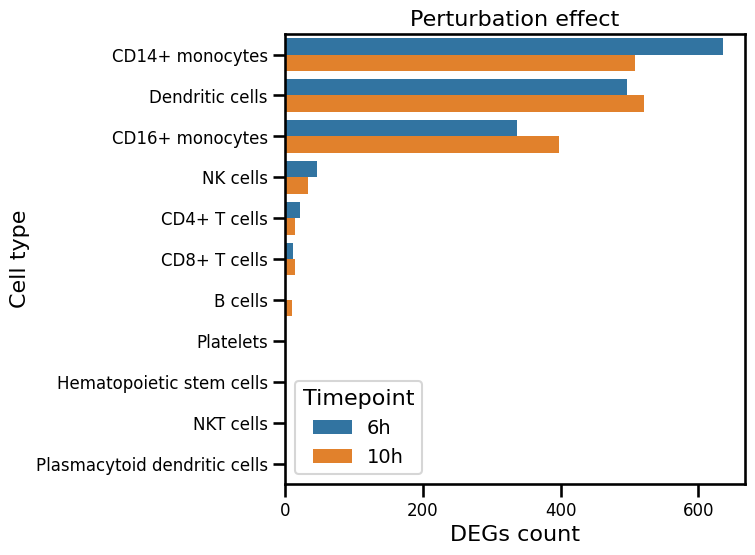

In [9]:
cell_types = adata.obs['cell_type_harmonized'].unique()
timepoints = ['6h_LPS', '10h_LPS']
results = []

for tp in timepoints:
    unperturbed = f'unperturbed_{tp}'
    perturbed   = f'perturbed_{tp}'

    for ct in cell_types:
        mask_pert = (adata.obs['status_time'] == perturbed) & (adata.obs['cell_type_harmonized'] == ct)
        mask_unpt = (adata.obs['status_time'] == unperturbed) & (adata.obs['cell_type_harmonized'] == ct)

        if mask_pert.sum() == 0 or mask_unpt.sum() == 0:
            continue

        sub_adata = adata[mask_pert | mask_unpt].copy()
        sub_adata.obs['group'] = 'unperturbed'
        sub_adata.obs.loc[sub_adata.obs['status_time'] == perturbed, 'group'] = 'perturbed'
        sub_adata.obs['group'] = sub_adata.obs['group'].astype('category')

        sc.tl.rank_genes_groups(sub_adata, groupby='group', reference='unperturbed',method='wilcoxon')
        degs = sc.get.rank_genes_groups_df(sub_adata, group='perturbed') 
        deg_count = (degs['pvals_adj'] < 0.05).sum()
        results.append({'cell_type': ct, 'timepoint': tp, 'deg_count': deg_count})

df = pd.DataFrame(results)
df_sorted = df.sort_values(by='deg_count', ascending=False)
df_sorted['timepoint'] = df_sorted['timepoint'].replace({
    '6h_LPS': '6h',
    '10h_LPS': '10h'
})
sns.set_context("talk", font_scale=1.2)  
plt.figure(figsize=(8, 6))
sns.barplot(data=df_sorted, y='cell_type', x='deg_count', hue='timepoint')
plt.ylabel('Cell type', fontsize=16)
plt.xlabel('DEGs count', fontsize=16)
plt.title('Perturbation effect', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Timepoint', fontsize=14, title_fontsize=16)
plt.tight_layout()
plt.show()

Next, we subset the data to the myeloid lineage, which showed the strongest perturbation effect. Of course, you may subset the data to any other affected or cell types of interest relevant to your analysis.

In [10]:
adata = adata[adata.obs['cell_type_harmonized'].isin(['CD14 monocytes','Dendritic cells',
                                                     'CD16 monocytes'])].copy()

Because the var_names in the AnnData object are stored as Ensembl IDs, we reload the original dataset to obtain the mapping needed to convert them into gene symbols.

In [11]:
adata_full = sc.read('/nfs/team361/am74/Cytomeister/Evaluation_datasets/LPS/full_lps.h5ad')

Since the original reference data is raw, we need to normalize and log-transform it before we can compare it with other results.

In [12]:
sc.pp.normalize_total(adata_full)
sc.pp.log1p(adata_full)

We convert the var_names in the original object from gene symbols to their corresponding Ensembl IDs.

In [17]:
adata_full.var_names = adata_full.var['ensembl_id-0']

Since the var_names in the perturbation object are stored as Ensembl IDs, we map them to their corresponding gene symbols using the original object.

In [14]:
mapping = adata_full.var['gene_ids-0'].to_dict()
adata.var_names = adata.var_names.map(mapping)
adata = adata[:, adata.var_names.notnull()].copy()

We next calculate the DEGs within the myeloid lineage, as this lineage showed the strongest response to perturbation. Specifically, we compute DEGs at each timepoint by comparing perturbed counts against the unperturbed counts (used as reference). From this, we identify upregulated and downregulated DEGs separately for each timepoint, which are then used for enrichment analysis.

In [26]:
deg_results = {}

for tp in ["6h", "10h"]:
    pert = f"perturbed_{tp}_LPS"
    unpert = f"unperturbed_{tp}_LPS"

    ad = adata[adata.obs["status_time"].isin([pert, unpert])].copy()
    ad.obs["cond"] = ad.obs["status_time"].map({pert: "pert", unpert: "unpert"}).astype("category")

    sc.tl.rank_genes_groups(ad, groupby="cond", groups=["pert"], reference="unpert",
                            method="wilcoxon", corr_method="benjamini-hochberg")

    de = sc.get.rank_genes_groups_df(ad, group="pert")

    sig = de[(de["pvals_adj"] < 0.05)]
    up = sig[sig["logfoldchanges"] > 0]
    down = sig[sig["logfoldchanges"] < 0]
    deg_results[tp] = {"up": up["names"].tolist(), "down": down["names"].tolist()}

We then apply GSEApy to perform enrichment analysis of the DEGs identified at each timepoint.

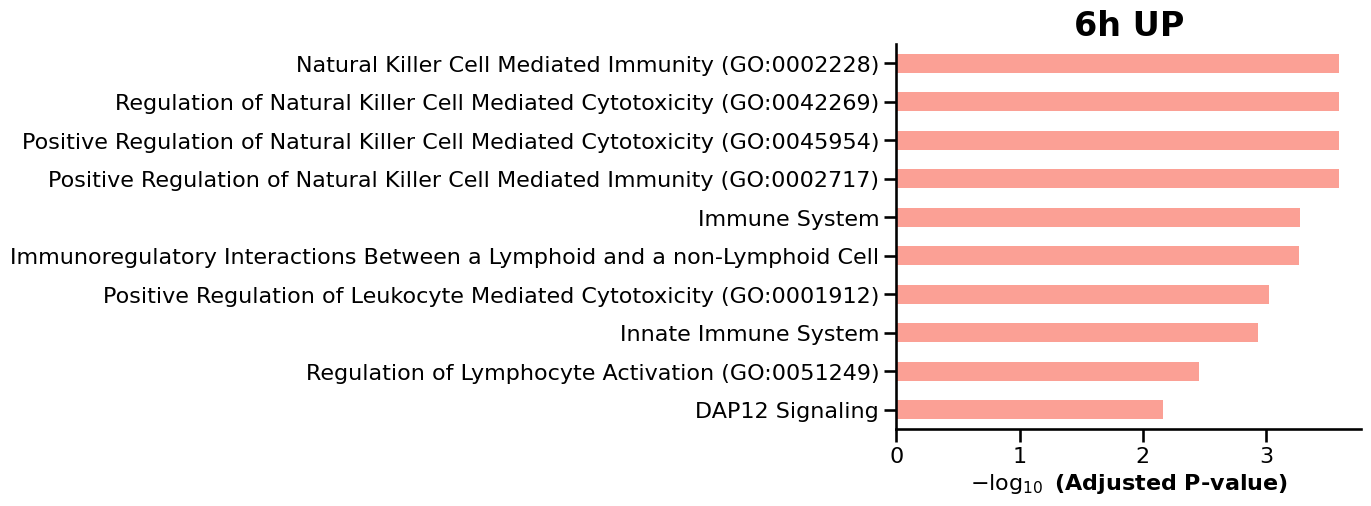

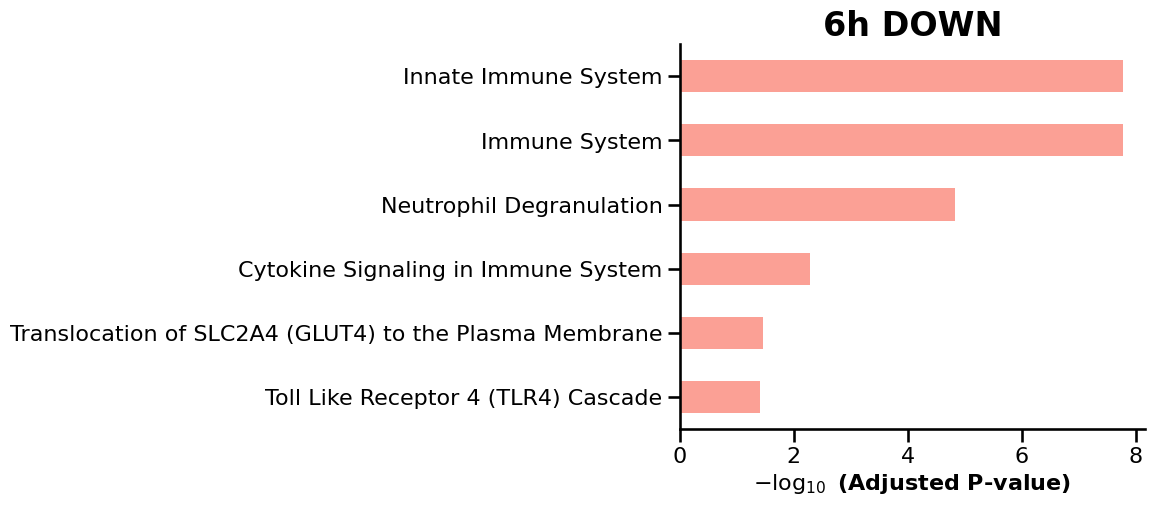

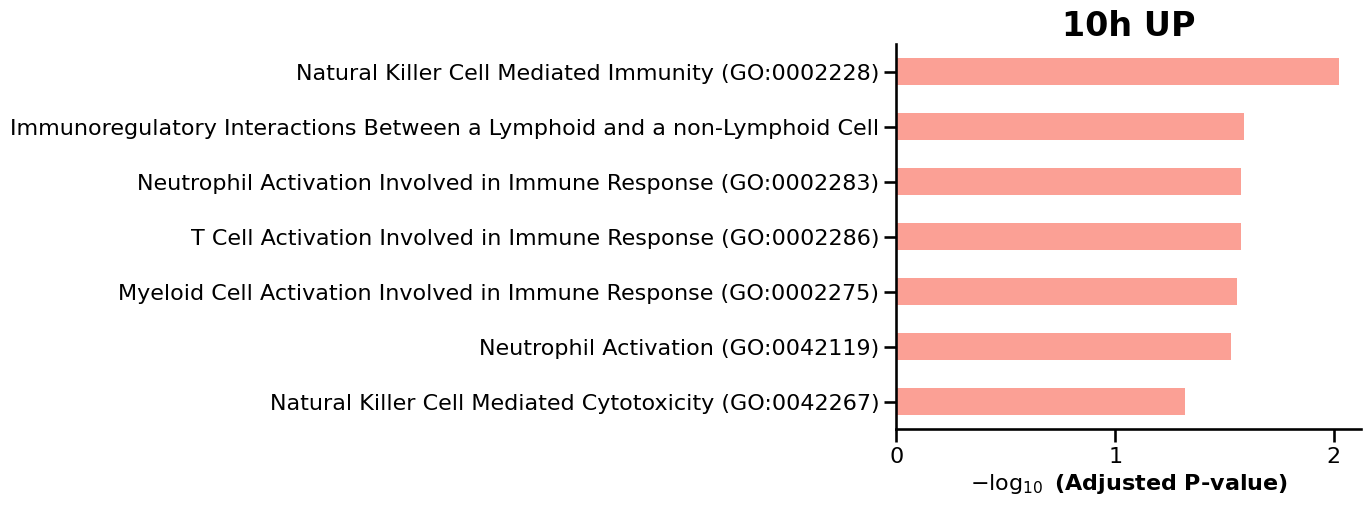

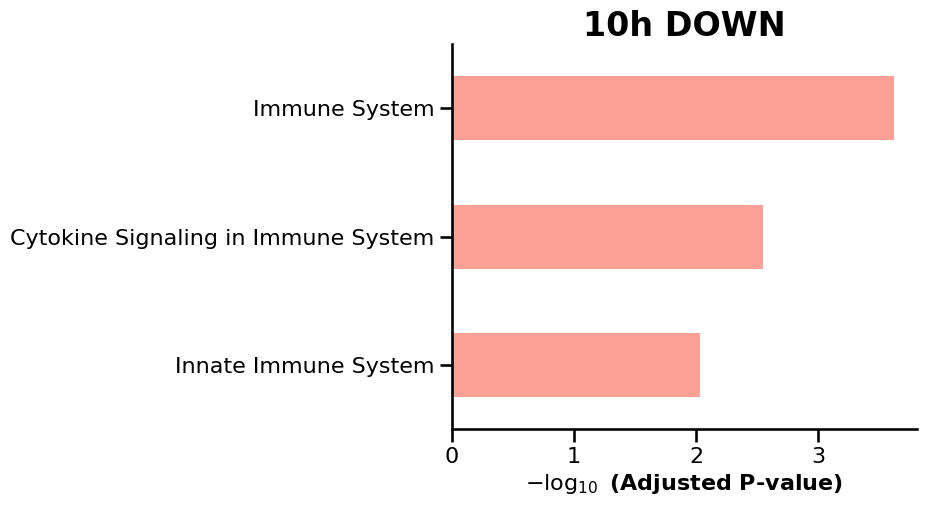

In [41]:
for tp, res in deg_results.items():
    for label, genes in res.items():
        if len(genes) == 0:
            continue

        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=["Reactome_Pathways_2024","GO_Biological_Process_2025"],  
            organism="Human",
            outdir=None,
            background = list(adata.var_names) ,
        )

        df = enr.results.sort_values("Adjusted P-value").head(15)

        ax = gp.barplot(df, column="Adjusted P-value", title=f"{tp} {label.upper()}", figsize=(6, 5))
        plt.show()